# Human Baseline: X5 RetailHero Uplift Modeling

Identifies **persuadable** customers (buy only when promoted) and flags where promotion is wasted.

**Pipeline:** Data loading (fetch_x5) → Feature engineering → Split 70/15/15 → Model grid training → Hyperparameter tuning → Champion selection → XAI → Customer segmentation → Policy analysis

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklift.datasets import fetch_x5

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier; HAS_XGB = True
except ImportError:
    HAS_XGB = False; print('XGBoost not installed')

try:
    from lightgbm import LGBMClassifier; HAS_LGB = True
except ImportError:
    HAS_LGB = False; print('LightGBM not installed')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path('artifacts/human_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Output dir:', OUTPUT_DIR)


Setup complete. Output dir: artifacts\human_baseline


## 1. Data Loading & EDA

`fetch_x5()` downloads and caches the dataset (~200 MB on first run).

In [2]:
import io as _io
import builtins as _bt

# fetch_x5 opens a .rst file without specifying encoding; on Windows the
# default codec (GBK) can't decode the UTF-8 content.  Patch open() only
# for the duration of that call, anchoring to io.open so the reference
# can never accidentally point back to our own wrapper.
def _utf8_open(file, mode='r', *a, **kw):
    if 'b' not in str(mode) and 'encoding' not in kw:
        kw['encoding'] = 'utf-8'
    return _io.open(file, mode, *a, **kw)

print('Loading X5 RetailHero dataset via fetch_x5()...')
print('(First run downloads ~200 MB — cached afterwards)')
t0 = time.time()

_bt.open = _utf8_open
try:
    dataset = fetch_x5()
finally:
    _bt.open = _io.open   # always restore, even if fetch_x5 raises

data      = dataset.data
target    = dataset.target      # Series: binary purchase indicator
treatment = dataset.treatment   # Series: binary coupon flag
clients   = data.clients        # demographics: client_id, first_issue_date, first_redeem_date, age, gender
train_raw = data.train          # labeled rows: client_id, first_issue_date, first_redeem_date
purchases = data.purchases      # full transaction history

print(f'Loaded in {time.time()-t0:.1f}s')
print(f'clients  : {clients.shape}   cols={list(clients.columns)}')
print(f'train_raw: {train_raw.shape} cols={list(train_raw.columns)}')
print(f'purchases: {purchases.shape} cols={list(purchases.columns)[:8]}...')


Loading X5 RetailHero dataset via fetch_x5()...
(First run downloads ~200 MB — cached afterwards)
Loaded in 178.0s
clients  : (400162, 5)   cols=['client_id', 'first_issue_date', 'first_redeem_date', 'age', 'gender']
train_raw: (200039, 1) cols=['client_id']
purchases: (45786568, 13) cols=['client_id', 'transaction_id', 'transaction_datetime', 'regular_points_received', 'express_points_received', 'regular_points_spent', 'express_points_spent', 'purchase_sum']...


In [3]:
labeled_raw = train_raw.copy().reset_index(drop=True)
labeled_raw['target']    = target.values
labeled_raw['treatment'] = treatment.values
labeled_raw['client_id'] = labeled_raw['client_id'].astype(str)
clients['client_id']     = clients['client_id'].astype(str)
purchases['client_id']   = purchases['client_id'].astype(str)

ENTITY_KEY    = 'client_id'
TREATMENT_COL = 'treatment'
TARGET_COL    = 'target'

n_treated = int(treatment.sum())
n_control = int((treatment == 0).sum())
rr_t = float(target[treatment == 1].mean())
rr_c = float(target[treatment == 0].mean())
print(f'Treated  : {n_treated:,} ({n_treated/len(treatment):.1%})')
print(f'Control  : {n_control:,} ({n_control/len(treatment):.1%})')
print(f'RR_treat : {rr_t:.4f}  |  RR_ctrl : {rr_c:.4f}  |  ATE : {rr_t-rr_c:+.4f}')
display(pd.crosstab(labeled_raw['treatment'], labeled_raw['target'], margins=True))


Treated  : 99,981 (50.0%)
Control  : 100,058 (50.0%)
RR_treat : 0.6365  |  RR_ctrl : 0.6033  |  ATE : +0.0332


target,0,1,All
treatment,,,
0,39695,60363,100058
1,36342,63639,99981
All,76037,124002,200039


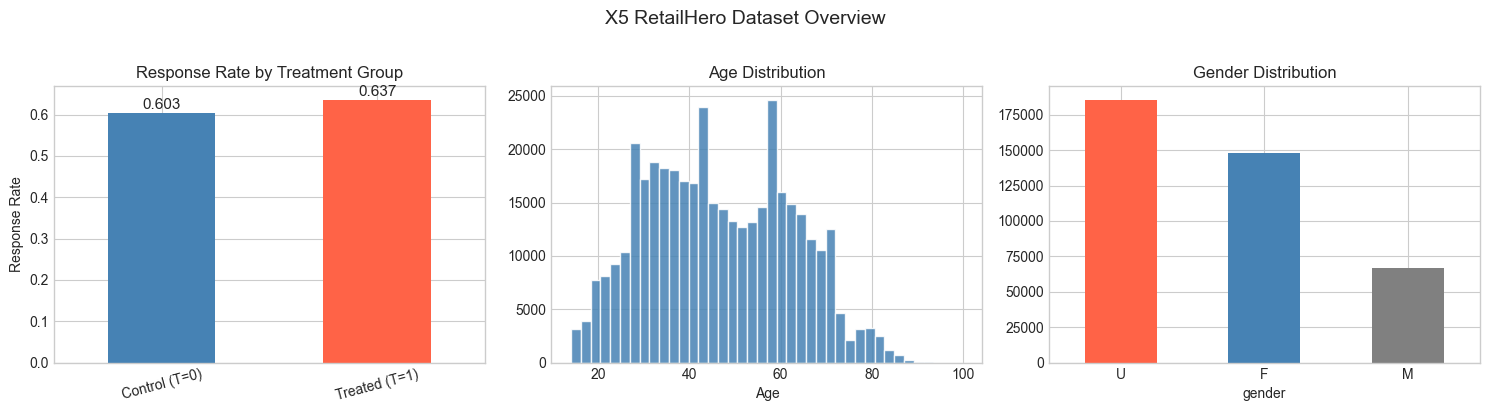

Purchase date range: 2018-11-21 21:02:33 to 2019-03-18 23:40:03


,purchase_sum,product_quantity,regular_points_received,regular_points_spent
count,45786568.0000,45786568.0000,45786568.0000,45786568.0000
mean,777.5215,1.2472,8.0499,-5.3126
std,796.5350,3.1376,12.6850,36.0365
min,0.0000,0.0000,0.0000,-5066.0000
25%,286.0000,1.0000,1.4000,0.0000
50%,539.0000,1.0000,3.8000,0.0000
75%,976.0000,1.0000,10.3000,0.0000
max,35149.0400,14941.0000,2399.0000,0.0000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rr = pd.Series({'Control (T=0)': rr_c, 'Treated (T=1)': rr_t})
rr.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], rot=15)
axes[0].set_title('Response Rate by Treatment Group')
axes[0].set_ylabel('Response Rate')
for bar, val in zip(axes[0].patches, rr):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)

age_v = pd.to_numeric(clients['age'], errors='coerce').dropna()
age_v = age_v[(age_v >= 14) & (age_v <= 100)]
axes[1].hist(age_v, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Age Distribution'); axes[1].set_xlabel('Age')

gc = clients['gender'].fillna('U').value_counts()
gc.plot(kind='bar', ax=axes[2], color=['tomato', 'steelblue', 'gray'], rot=0)
axes[2].set_title('Gender Distribution')

plt.suptitle('X5 RetailHero Dataset Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_overview.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Purchase date range: {purchases["transaction_datetime"].min()} to {purchases["transaction_datetime"].max()}')
display(purchases[['purchase_sum', 'product_quantity', 'regular_points_received',
                   'regular_points_spent']].describe())


## 2. Feature Engineering

Customer-level table (one row per customer) with demographic, lifetime RFM, and rolling 30d/60d/90d features. No leakage: `target` and `treatment` never used as features.

In [5]:
labeled_ids = set(labeled_raw['client_id'])
print(f'Labeled customers: {len(labeled_ids):,}')

def build_demographic_features(clients_df, labeled_df):
    demo = labeled_df[['client_id']].copy()
    demo = demo.merge(
        clients_df[['client_id', 'age', 'gender', 'first_issue_date', 'first_redeem_date']],
        on='client_id', how='left'
    )

    age = pd.to_numeric(demo['age'], errors='coerce')
    demo['age_clean']       = age.where(age.between(14, 100), np.nan).fillna(-1)
    demo['age_invalid_flag']= (~age.between(14, 100) | age.isna()).astype(int)

    bins = [0, 25, 35, 45, 55, 65, 200]
    lbls = ['le25', '26_35', '36_45', '46_55', '56_65', 'gt65']
    bkt  = pd.cut(demo['age_clean'].replace(-1, np.nan), bins=bins, labels=lbls, right=True)
    for lb in lbls:
        demo[f'age_{lb}'] = (bkt == lb).astype(int)

    gender = demo['gender'].fillna('U').astype(str).str.upper()
    for g in ['F', 'M', 'U']:
        demo[f'gender_{g}'] = (gender == g).astype(int)

    ref    = pd.Timestamp('2019-03-18')
    issue  = pd.to_datetime(demo['first_issue_date'],  errors='coerce')
    redeem = pd.to_datetime(demo['first_redeem_date'], errors='coerce')
    demo['issue_date_missing']   = issue.isna().astype(int)
    demo['account_age_days']     = (ref - issue).dt.total_seconds().div(86400).fillna(-1).round(1)
    demo['has_redeemed']         = (~redeem.isna()).astype(int)
    demo['days_to_first_redeem'] = (redeem - issue).dt.total_seconds().div(86400).fillna(-1).round(1)

    return demo.drop(columns=['age', 'gender', 'first_issue_date', 'first_redeem_date'])

demo_features = build_demographic_features(clients, labeled_raw)
print(f'Demographic features: {demo_features.shape}')
display(demo_features.head(3))


Labeled customers: 200,039
Demographic features: (200039, 16)


,client_id,age_clean,age_invalid_flag,age_le25,age_26_35,age_36_45,age_46_55,age_56_65,age_gt65,gender_F,gender_M,gender_U,issue_date_missing,account_age_days,has_redeemed,days_to_first_redeem
0,000012768d,45.0000,0,0,0,1,0,0,0,0,0,1,0,589.3000,1,152.2000
1,000036f903,72.0000,0,0,0,0,0,0,1,1,0,0,0,706.4000,1,12.9000
2,00010925a5,83.0000,0,0,0,0,0,0,1,0,0,1,0,236.3000,1,52.0000


In [6]:
def build_purchase_features(purchases_df, clients_df, cohort_ids, windows=[30, 60, 90]):
    t0 = time.time()
    purch = purchases_df[purchases_df['client_id'].isin(cohort_ids)].copy()
    purch['transaction_datetime'] = pd.to_datetime(purch['transaction_datetime'], errors='coerce')

    for col in ['purchase_sum', 'product_quantity', 'regular_points_received',
                'express_points_received', 'regular_points_spent', 'express_points_spent']:
        if col in purch.columns:
            purch[col] = pd.to_numeric(purch[col], errors='coerce').fillna(0.0)

    # Anti-leakage: remove pre-card-issue transactions
    issue_map = (clients_df.set_index('client_id')['first_issue_date']
                 .apply(lambda x: pd.to_datetime(x, errors='coerce')).to_dict())
    purch['__iss__'] = purch['client_id'].map(issue_map)
    purch = purch[~(purch['__iss__'].notna() & (purch['transaction_datetime'] < purch['__iss__']))]
    purch = purch.drop(columns=['__iss__'])

    # Collapse product lines to transaction level
    if 'transaction_id' in purch.columns:
        txn = purch.groupby(['client_id', 'transaction_id', 'transaction_datetime'], as_index=False).agg(
            purchase_sum=('purchase_sum', 'max'),
            product_quantity=('product_quantity', 'sum'),
            rpr=('regular_points_received', 'max'),
            epr=('express_points_received', 'max'),
            rps=('regular_points_spent', 'max'),
            eps=('express_points_spent', 'max'),
        )
        txn['points_received'] = txn['rpr'] + txn['epr']
        txn['points_spent']    = txn['rps'] + txn['eps']
        txn = txn.drop(columns=['rpr', 'epr', 'rps', 'eps'])
    else:
        txn = purch.copy()
        txn['points_received'] = txn.get('regular_points_received', 0) + txn.get('express_points_received', 0)
        txn['points_spent']    = txn.get('regular_points_spent', 0)    + txn.get('express_points_spent', 0)

    ref_dt = txn['transaction_datetime'].max()
    print(f'  Reference date: {ref_dt}  |  Txns after anti-leakage: {len(txn):,}')

    def agg_w(df, sfx, ref):
        base = pd.DataFrame({'client_id': list(cohort_ids)})
        if df.empty:
            for c in ['txn_count','purchase_sum','avg_txn','basket_qty','recency_days',
                      'pts_recv','pts_spent','pts_recv_ratio','pts_spent_ratio']:
                base[f'{c}_{sfx}'] = 0.0 if c != 'recency_days' else -1.0
            return base
        g = df.groupby('client_id', as_index=False).agg(
            txn_count=('transaction_datetime', 'count'),
            purchase_sum=('purchase_sum', 'sum'),
            basket_qty=('product_quantity', 'sum'),
            last_dt=('transaction_datetime', 'max'),
            pts_recv=('points_received', 'sum'),
            pts_spent=('points_spent', 'sum'),
        )
        g = base.merge(g, on='client_id', how='left')
        cnt = g['txn_count'].fillna(0);  ps  = g['purchase_sum'].fillna(0)
        pr  = g['pts_recv'].fillna(0);   psp = g['pts_spent'].fillna(0)
        bq  = g['basket_qty'].fillna(0)
        sc  = cnt.where(cnt > 0);        sps = ps.where(ps > 0)
        rec = (ref - pd.to_datetime(g['last_dt'], errors='coerce')).dt.total_seconds().div(86400).fillna(-1)
        r = pd.DataFrame({'client_id': g['client_id']})
        r[f'txn_count_{sfx}']       = cnt.astype(int)
        r[f'purchase_sum_{sfx}']    = ps.round(4)
        r[f'avg_txn_{sfx}']         = (ps / sc).fillna(0).round(4)
        r[f'basket_qty_{sfx}']      = bq.round(4)
        r[f'recency_days_{sfx}']    = rec.round(2)
        r[f'pts_recv_{sfx}']        = pr.round(4)
        r[f'pts_spent_{sfx}']       = psp.round(4)
        r[f'pts_recv_ratio_{sfx}']  = (pr / sps).fillna(0).round(4)
        r[f'pts_spent_ratio_{sfx}'] = (psp / sps).fillna(0).round(4)
        return r

    frames = [agg_w(txn, 'lifetime', ref_dt)]
    for w in windows:
        cutoff = ref_dt - pd.Timedelta(days=w)
        frames.append(agg_w(txn[txn['transaction_datetime'] >= cutoff], f'{w}d', ref_dt))
    result = frames[0]
    for f in frames[1:]:
        result = result.merge(f, on='client_id', how='left')
    print(f'  Purchase features: {result.shape}  elapsed={time.time()-t0:.0f}s')
    return result

print('Building purchase features...')
purchase_features = build_purchase_features(purchases, clients, labeled_ids)
display(purchase_features.head(3))


Building purchase features...
  Reference date: 2019-03-18 23:19:28  |  Txns after anti-leakage: 3,997,820
  Purchase features: (200039, 37)  elapsed=194s


,client_id,txn_count_lifetime,purchase_sum_lifetime,avg_txn_lifetime,basket_qty_lifetime,recency_days_lifetime,pts_recv_lifetime,pts_spent_lifetime,pts_recv_ratio_lifetime,pts_spent_ratio_lifetime,...,pts_spent_ratio_60d,txn_count_90d,purchase_sum_90d,avg_txn_90d,basket_qty_90d,recency_days_90d,pts_recv_90d,pts_spent_90d,pts_recv_ratio_90d,pts_spent_ratio_90d
0,43703c1094,9,2176.8900,241.8767,40.0000,21.4100,14.3000,0.0000,0.0066,0.0000,...,0.0000,7,1686.8900,240.9843,28.0000,21.4100,12.0000,0.0000,0.0071,0.0000
1,c465539362,13,8767.7900,674.4454,162.0000,1.5600,77.5000,-14.0000,0.0088,-0.0016,...,0.0000,10,6674.2400,667.4240,120.0000,1.5600,58.9000,0.0000,0.0088,0.0000
2,5868ea5429,8,3454.9900,431.8738,75.0000,0.7100,65.0000,-68.0000,0.0188,-0.0197,...,-0.0254,5,2675.8200,535.1640,65.0000,0.7100,57.4000,-68.0000,0.0215,-0.0254


In [7]:
feature_table = demo_features.merge(purchase_features, on='client_id', how='left')
assert feature_table['client_id'].duplicated().sum() == 0, 'Duplicate client_ids!'
assert 'target'    not in feature_table.columns, 'Leakage: target!'
assert 'treatment' not in feature_table.columns, 'Leakage: treatment!'
print(f'Feature table: {feature_table.shape}  — validation passed')
null_pct = feature_table.isnull().mean()
if null_pct.max() > 0:
    display(null_pct[null_pct > 0].sort_values(ascending=False))
else:
    print('No nulls in feature table.')
feature_table.to_csv(OUTPUT_DIR / 'feature_table.csv', index=False)

# `describe().T["count"]` is the non-null row count per feature. Because the
# feature table is fully imputed, those counts should all equal len(feature_table).
feature_summary = feature_table.describe().T.rename(columns={'count': 'non_null_count'})
feature_summary['non_null_count'] = feature_summary['non_null_count'].astype(int)
feature_summary.insert(1, 'missing_count', feature_table.isna().sum().reindex(feature_summary.index).astype(int))
feature_summary.insert(2, 'missing_pct', feature_table.isna().mean().reindex(feature_summary.index).round(4))
feature_summary.insert(3, 'unique_values', feature_table.nunique(dropna=False).reindex(feature_summary.index).astype(int))
display(feature_summary)


Feature table: (200039, 52)  — validation passed
No nulls in feature table.


,non_null_count,missing_count,missing_pct,unique_values,mean,std,min,25%,50%,75%,max
age_clean,200039,0,0.0000,86,46.2120,16.1491,-1.0000,33.0000,45.0000,59.0000,100.0000
age_invalid_flag,200039,0,0.0000,2,0.0044,0.0663,0.0000,0.0000,0.0000,0.0000,1.0000
age_le25,200039,0,0.0000,2,0.0926,0.2899,0.0000,0.0000,0.0000,0.0000,1.0000
age_26_35,200039,0,0.0000,2,0.2007,0.4005,0.0000,0.0000,0.0000,0.0000,1.0000
age_36_45,200039,0,0.0000,2,0.2086,0.4063,0.0000,0.0000,0.0000,0.0000,1.0000
age_46_55,200039,0,0.0000,2,0.1699,0.3755,0.0000,0.0000,0.0000,0.0000,1.0000
age_56_65,200039,0,0.0000,2,0.1925,0.3942,0.0000,0.0000,0.0000,0.0000,1.0000
age_gt65,200039,0,0.0000,2,0.1314,0.3378,0.0000,0.0000,0.0000,0.0000,1.0000
gender_F,200039,0,0.0000,2,0.3684,0.4824,0.0000,0.0000,0.0000,1.0000,1.0000
gender_M,200039,0,0.0000,2,0.1675,0.3734,0.0000,0.0000,0.0000,0.0000,1.0000


## 3. Train / Validation / Test Split (70 / 15 / 15)

Stratified on the joint `treatment × target` key to preserve both rates across splits.

In [8]:
labeled = labeled_raw[['client_id', TARGET_COL, TREATMENT_COL]].merge(
    feature_table, on='client_id', how='inner')
print(f'Modeling frame: {labeled.shape}')

MIN_ROWS_PER_PARTITION = 2
N_REQUESTED_PARTITIONS = 3
MIN_STRATUM_SIZE = MIN_ROWS_PER_PARTITION * N_REQUESTED_PARTITIONS

def _is_feasible_stratification(key, min_size=MIN_STRATUM_SIZE):
    counts = pd.Series(key).value_counts()
    return (not counts.empty) and bool((counts >= min_size).all())

def determine_notebook_stratification(df):
    joint_key = df[TREATMENT_COL].astype(str) + ':' + df[TARGET_COL].astype(str)
    if _is_feasible_stratification(joint_key):
        return 'joint_treatment_outcome', joint_key, []

    warnings_ = ['joint treatment/outcome stratification infeasible; trying treatment-only stratification']
    treatment_key = df[TREATMENT_COL]
    if _is_feasible_stratification(treatment_key):
        return 'treatment_only', treatment_key, warnings_

    warnings_.append('treatment-only stratification infeasible; falling back to random split')
    return 'random', None, warnings_

def _safe_stratify(values):
    if values is None:
        return None
    counts = pd.Series(values).value_counts()
    return values if (not counts.empty and int(counts.min()) >= 2) else None

split_strategy, strat, split_warnings = determine_notebook_stratification(labeled)
print(f'Stratification strategy: {split_strategy}')
for w in split_warnings:
    print('  warning:', w)
if strat is not None:
    print('Stratification key:'); display(pd.Series(strat).value_counts())

idx_all = np.arange(len(labeled))
idx_train, idx_rest = train_test_split(
    idx_all, test_size=0.30, random_state=RANDOM_SEED, stratify=_safe_stratify(strat))
rest_strat = _safe_stratify(strat.iloc[idx_rest] if strat is not None else None)
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.50, random_state=RANDOM_SEED, stratify=rest_strat)

train_df = labeled.iloc[idx_train].reset_index(drop=True)
val_df   = labeled.iloc[idx_val].reset_index(drop=True)
test_df  = labeled.iloc[idx_test].reset_index(drop=True)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

print(f'train={len(train_df):,} ({len(train_df)/len(labeled):.0%})  '
      f'val={len(val_df):,} ({len(val_df)/len(labeled):.0%})  '
      f'test={len(test_df):,} ({len(test_df)/len(labeled):.0%})')
print(f'CV training pool={len(train_val_df):,} ({len(train_val_df)/len(labeled):.0%}); held-out test remains untouched')
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rt = df.loc[df[TREATMENT_COL]==1, TARGET_COL].mean()
    rc = df.loc[df[TREATMENT_COL]==0, TARGET_COL].mean()
    print(f'  {name}: treat={df[TREATMENT_COL].mean():.3f}  target={df[TARGET_COL].mean():.3f}  '
          f'RR_t={rt:.3f}  RR_c={rc:.3f}  ATE={rt-rc:+.4f}')

FEATURE_COLS = [c for c in train_df.columns
                if c not in {ENTITY_KEY, TREATMENT_COL, TARGET_COL}]
print(f'\nFeatures: {len(FEATURE_COLS)}  |  {FEATURE_COLS[:10]} ...')


Modeling frame: (200039, 54)
Stratification strategy: joint_treatment_outcome
Stratification key:


1:1    63639
0:1    60363
0:0    39695
1:0    36342
Name: count, dtype: int64

train=140,027 (70%)  val=30,006 (15%)  test=30,006 (15%)
CV training pool=170,033 (85%); held-out test remains untouched
  Train: treat=0.500  target=0.620  RR_t=0.637  RR_c=0.603  ATE=+0.0332
  Val: treat=0.500  target=0.620  RR_t=0.636  RR_c=0.603  ATE=+0.0332
  Test: treat=0.500  target=0.620  RR_t=0.637  RR_c=0.603  ATE=+0.0332

Features: 51  |  ['age_clean', 'age_invalid_flag', 'age_le25', 'age_26_35', 'age_36_45', 'age_46_55', 'age_56_65', 'age_gt65', 'gender_F', 'gender_M'] ...


## 4. Uplift Metric Functions

Normalized Qini AUC, raw Qini AUC, Uplift AUC, Uplift@k, and decile table implemented from scratch (matching `src/uplift/metrics.py` for a fair comparison with the agentic pipeline).

In [9]:
CUTOFF_GRID = [0.05, 0.10, 0.20, 0.30]

def _as_1d_array(values, name):
    arr = np.asarray(values)
    if arr.ndim != 1:
        raise ValueError(f'{name} must be a 1D array')
    return arr

def _validate_uplift_inputs(y, t, u):
    y = _as_1d_array(y, 'y_true').astype(int)
    t = _as_1d_array(t, 'treatment').astype(int)
    u = _as_1d_array(u, 'uplift').astype(float)
    if not (len(y) == len(t) == len(u)):
        raise ValueError('y_true, treatment, and uplift must have the same length')
    if len(y) == 0:
        raise ValueError('uplift metrics require at least one row')
    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError('y_true must be binary 0/1')
    if not set(np.unique(t)).issubset({0, 1}):
        raise ValueError('treatment must be binary 0/1')
    if len(np.unique(t)) < 2:
        raise ValueError('uplift metrics require both treatment and control rows')
    if np.isnan(u).any():
        raise ValueError('uplift contains NaN values')
    return y, t, u

def _sf(y, t, u):
    y, t, u = _validate_uplift_inputs(y, t, u)
    d = pd.DataFrame({'target': y,
                      'treatment': t,
                      'uplift': u})
    return d.sort_values('uplift', ascending=False, kind='mergesort').reset_index(drop=True)

def qini_curve_data(y, t, u):
    f = _sf(y, t, u); tr = (f['treatment'] == 1); ct = ~tr
    qt = tr.cumsum(); qc = ct.cumsum()
    yt = (f['target'] * tr.astype(int)).cumsum()
    yc = (f['target'] * ct.astype(int)).cumsum()
    sc = qt / qc.replace(0, np.nan)
    return pd.DataFrame({'fraction': (np.arange(len(f))+1)/len(f),
                         'qini': (yt - sc.fillna(0) * yc).astype(float)})

def uplift_curve_data(y, t, u):
    f = _sf(y, t, u); tr = (f['treatment'] == 1); ct = ~tr
    qt = tr.cumsum(); qc = ct.cumsum()
    yt = (f['target'] * tr.astype(int)).cumsum()
    yc = (f['target'] * ct.astype(int)).cumsum()
    ur = ((yt / qt.replace(0, np.nan)) - (yc / qc.replace(0, np.nan))).fillna(0).astype(float)
    return pd.DataFrame({'fraction': (np.arange(len(f))+1)/len(f), 'uplift': ur})

def raw_qini_auc(y, t, u):
    c = qini_curve_data(y, t, u); return round(float(np.trapz(c['qini'], c['fraction'])), 6)

def _qini_count_curve_arrays(y, t, u):
    y, t, u = _validate_uplift_inputs(y, t, u)
    order = np.argsort(u, kind='mergesort')[::-1]
    y = y[order]; t = t[order]; u = u[order]
    y_control = y.copy(); y_control[t == 1] = 0
    y_treatment = y.copy(); y_treatment[t == 0] = 0
    distinct_value_indices = np.where(np.diff(u))[0]
    threshold_indices = np.r_[distinct_value_indices, u.size - 1]
    num_treatment = np.cumsum(t)[threshold_indices]
    num_all = threshold_indices + 1
    num_control = num_all - num_treatment
    treatment_responders = np.cumsum(y_treatment)[threshold_indices]
    control_responders = np.cumsum(y_control)[threshold_indices]
    curve_values = treatment_responders - control_responders * np.divide(
        num_treatment, num_control,
        out=np.zeros_like(num_treatment, dtype=float),
        where=num_control != 0,
    )
    if num_all.size == 0 or curve_values[0] != 0 or num_all[0] != 0:
        num_all = np.r_[0, num_all]
        curve_values = np.r_[0, curve_values]
    return num_all.astype(float), curve_values.astype(float)

def _perfect_qini_count_curve_arrays(y, t, negative_effect=False):
    y, t, _ = _validate_uplift_inputs(y, t, np.zeros(len(y)))
    if negative_effect:
        oracle_uplift = y * t - y * (1 - t)
        return _qini_count_curve_arrays(y, t, oracle_uplift)
    treated = t == 1
    control = ~treated
    random_ratio = y[treated].sum() - treated.sum() * y[control].sum() / control.sum()
    return (np.array([0.0, float(random_ratio), float(len(y))]),
            np.array([0.0, float(random_ratio), float(random_ratio)]))

def normalized_qini_auc(y, t, u, negative_effect=False):
    x_actual, y_actual = _qini_count_curve_arrays(y, t, u)
    x_perfect, y_perfect = _perfect_qini_count_curve_arrays(y, t, negative_effect=negative_effect)
    x_baseline = pd.Series([0.0, float(x_perfect[-1])])
    y_baseline = pd.Series([0.0, float(y_perfect[-1])])
    baseline_area = float(np.trapz(y_baseline, x_baseline))
    perfect_area = float(np.trapz(pd.Series(y_perfect), pd.Series(x_perfect)))
    actual_area = float(np.trapz(pd.Series(y_actual), pd.Series(x_actual)))
    denominator = perfect_area - baseline_area
    if denominator == 0:
        return 0.0
    return round(float((actual_area - baseline_area) / denominator), 6)

# Backward-compatible alias: the notebook's reported Qini AUC is normalized.
def qini_auc(y, t, u):
    return normalized_qini_auc(y, t, u)

def uplift_auc(y, t, u):
    c = uplift_curve_data(y, t, u); return round(float(np.trapz(c['uplift'], c['fraction'])), 6)

def uplift_at_k(y, t, u, k=0.3):
    if k <= 0 or k > 1:
        raise ValueError('k must be in (0, 1]')
    f = _sf(y, t, u); n = max(1, int(np.ceil(len(f)*k))); top = f.head(n)
    tr = top[top['treatment']==1]; ct = top[top['treatment']==0]
    if tr.empty or ct.empty: return float('nan')
    return round(float(tr['target'].mean() - ct['target'].mean()), 6)

def decile_table(y, t, u, n_bins=10):
    f = _sf(y, t, u); bins = np.array_split(f.index.to_numpy(), min(n_bins, len(f)))
    rows = []
    for i, idx in enumerate(bins, 1):
        p = f.loc[idx]; tr = p[p['treatment']==1]; ct = p[p['treatment']==0]
        tr_r = float(tr['target'].mean()) if not tr.empty else 0.0
        ct_r = float(ct['target'].mean()) if not ct.empty else 0.0
        rows.append({'decile': i, 'n': len(p), 'treated_n': len(tr), 'control_n': len(ct),
                     'treated_rr': round(tr_r,4), 'control_rr': round(ct_r,4),
                     'obs_uplift': round(tr_r-ct_r,4), 'pred_uplift': round(float(p['uplift'].mean()),4)})
    return pd.DataFrame(rows)

def eval_all(y, t, u, name='model'):
    metrics = {'model': name, 'normalized_qini_auc': normalized_qini_auc(y,t,u),
               'raw_qini_auc': raw_qini_auc(y,t,u), 'uplift_auc': uplift_auc(y,t,u)}
    for cutoff in CUTOFF_GRID:
        metrics[f'uplift@{int(round(cutoff * 100))}%'] = uplift_at_k(y,t,u,cutoff)
    return metrics

print('Metric functions ready.')


Metric functions ready.


## 5. Uplift Model Training

| Learner | Description |
|---|---|
| Random | Lower bound |
| Response model | P(Y=1\|X) as proxy — ignores treatment |
| T-Learner (two-model) | Separate models for T=1 / T=0; uplift = P_treat − P_ctrl |
| S-Learner (solo-model) | Single model with T as feature; counterfactual diff |
| Class transformation | Relabel y'=1 iff Y=T; uplift = 2P−1 |

In [10]:
def make_pipeline(base, seed, p=None):
    p = p or {}
    if base == 'logistic_regression':
        return Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=500, solver='liblinear', random_state=seed,
                                       C=p.get('C', 1.0)))])
    if base == 'gradient_boosting':
        return Pipeline([('imp', SimpleImputer(strategy='median')),
            ('clf', GradientBoostingClassifier(
                n_estimators=p.get('n_estimators', 100), learning_rate=p.get('learning_rate', 0.05),
                max_depth=p.get('max_depth', 3), subsample=p.get('subsample', 0.8),
                random_state=seed))])
    if base == 'random_forest':
        return Pipeline([('imp', SimpleImputer(strategy='median')),
            ('clf', RandomForestClassifier(
                n_estimators=p.get('n_estimators', 200), max_depth=p.get('max_depth', 10),
                min_samples_leaf=p.get('min_samples_leaf', 20), random_state=seed, n_jobs=-1))])
    if base == 'xgboost' and HAS_XGB:
        return Pipeline([('imp', SimpleImputer(strategy='median')),
            ('clf', XGBClassifier(
                n_estimators=p.get('n_estimators', 200), max_depth=p.get('max_depth', 5),
                learning_rate=p.get('learning_rate', 0.05), subsample=p.get('subsample', 0.8),
                colsample_bytree=p.get('colsample_bytree', 0.8),
                eval_metric='logloss', random_state=seed, verbosity=0))])
    if base == 'lightgbm' and HAS_LGB:
        return Pipeline([('imp', SimpleImputer(strategy='median')),
            ('clf', LGBMClassifier(
                n_estimators=p.get('n_estimators', 200), max_depth=p.get('max_depth', 5),
                learning_rate=p.get('learning_rate', 0.05), subsample=p.get('subsample', 0.8),
                colsample_bytree=p.get('colsample_bytree', 0.8),
                random_state=seed, verbose=-1, n_jobs=-1))])
    raise ValueError(f'Unknown: {base}')

def fit_clf(X, y, base, seed, p=None):
    ya = np.asarray(y).astype(int)
    if len(np.unique(ya)) < 2:
        class C:
            def __init__(self, v): self.v = v
            def predict_proba(self, X):
                proba = np.full(len(X), self.v, dtype=float)
                return np.column_stack([1.0 - proba, proba])
        return C(float(ya.mean()))
    clf = make_pipeline(base, seed, p); clf.fit(X, ya); return clf

def pp(m, X): return np.asarray(m.predict_proba(X))[:, 1]

class UpliftModel:
    def __init__(self, name, family, base, seed=42):
        self.name = name; self.family = family; self.base = base; self.seed = seed
        self.model = self.treat_model = self.ctrl_model = None; self.feat_cols = None

    def fit(self, df, fc, tc, yc, p=None):
        self.feat_cols = fc
        X = df[fc].apply(pd.to_numeric, errors='coerce')
        y = df[yc].astype(int); t = df[tc].astype(int)
        if self.family == 'random': pass
        elif self.family == 'response_model':
            self.model = fit_clf(X, y, self.base, self.seed, p)
        elif self.family == 'two_model':
            mask = (t == 1)
            self.treat_model = fit_clf(X[mask],  y[mask],  self.base, self.seed, p)
            self.ctrl_model  = fit_clf(X[~mask], y[~mask], self.base, self.seed, p)
        elif self.family == 'solo_model':
            Xs = X.copy(); Xs['__t__'] = t.values
            self.model = fit_clf(Xs, y, self.base, self.seed, p)
        elif self.family == 'class_transformation':
            self.model = fit_clf(X, (y == t).astype(int), self.base, self.seed, p)
        return self

    def predict_uplift(self, df):
        if self.family == 'random':
            return np.random.RandomState(self.seed).random_sample(len(df))
        X = df[self.feat_cols].apply(pd.to_numeric, errors='coerce')
        if self.family == 'response_model':    return pp(self.model, X)
        if self.family == 'two_model':         return pp(self.treat_model, X) - pp(self.ctrl_model, X)
        if self.family == 'solo_model':
            Xt = X.copy(); Xt['__t__'] = 1
            Xc = X.copy(); Xc['__t__'] = 0
            return pp(self.model, Xt) - pp(self.model, Xc)
        if self.family == 'class_transformation': return 2.0 * pp(self.model, X) - 1.0

print('UpliftModel + classifier factory ready.')

UpliftModel + classifier factory ready.


In [11]:
MODEL_GRID = [
    ('random_baseline',      'random',               'random'),
    ('response_lr',          'response_model',       'logistic_regression'),
    ('response_gbm',         'response_model',       'gradient_boosting'),
    ('two_model_lr',         'two_model',            'logistic_regression'),
    ('two_model_gbm',        'two_model',            'gradient_boosting'),
    ('two_model_rf',         'two_model',            'random_forest'),
    ('solo_model_lr',        'solo_model',           'logistic_regression'),
    ('solo_model_gbm',       'solo_model',           'gradient_boosting'),
    ('class_transform_lr',   'class_transformation', 'logistic_regression'),
    ('class_transform_gbm',  'class_transformation', 'gradient_boosting'),
]
if HAS_XGB:
    MODEL_GRID += [('two_model_xgb', 'two_model', 'xgboost'),
                   ('solo_model_xgb', 'solo_model', 'xgboost')]
if HAS_LGB:
    MODEL_GRID += [('two_model_lgbm', 'two_model', 'lightgbm'),
                   ('solo_model_lgbm', 'solo_model', 'lightgbm')]
print(f'{len(MODEL_GRID)} models in grid')
for n, f, b in MODEL_GRID:
    print(f'  {n}  ({f} / {b})')


14 models in grid
  random_baseline  (random / random)
  response_lr  (response_model / logistic_regression)
  response_gbm  (response_model / gradient_boosting)
  two_model_lr  (two_model / logistic_regression)
  two_model_gbm  (two_model / gradient_boosting)
  two_model_rf  (two_model / random_forest)
  solo_model_lr  (solo_model / logistic_regression)
  solo_model_gbm  (solo_model / gradient_boosting)
  class_transform_lr  (class_transformation / logistic_regression)
  class_transform_gbm  (class_transformation / gradient_boosting)
  two_model_xgb  (two_model / xgboost)
  solo_model_xgb  (solo_model / xgboost)
  two_model_lgbm  (two_model / lightgbm)
  solo_model_lgbm  (solo_model / lightgbm)


In [12]:
print('Runtime-conscious model screening + cross-validation...')
print('=' * 72)

CV_N_SPLITS = 5
CV_SHORTLIST_SIZE = 3
CV_SCORING_METRIC = 'normalized_qini_auc'
y_val = val_df[TARGET_COL].values
t_val = val_df[TREATMENT_COL].values

def _cv_splitter_and_key(df, n_splits=CV_N_SPLITS):
    joint_key = df[TREATMENT_COL].astype(str) + ':' + df[TARGET_COL].astype(str)
    if pd.Series(joint_key).value_counts().min() >= n_splits:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED), joint_key, 'joint_treatment_outcome'
    treatment_key = df[TREATMENT_COL].astype(str)
    if pd.Series(treatment_key).value_counts().min() >= n_splits:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED), treatment_key, 'treatment_only'
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED), None, 'random_kfold'

cv_splitter, cv_key, cv_strategy = _cv_splitter_and_key(train_val_df)
print(f'CV strategy: {CV_N_SPLITS}-fold {cv_strategy}; scoring={CV_SCORING_METRIC}')
print(f'Runtime control: holdout screens all models, then 5-fold CV refits only the top {CV_SHORTLIST_SIZE} non-random candidates.')

screen_models = {}
screen_rows = []
print()
print('Stage 1: fast holdout screening on the original validation split')
for name, family, base in MODEL_GRID:
    t0 = time.time()
    try:
        m = UpliftModel(name, family, base, seed=RANDOM_SEED)
        m.fit(train_df, FEATURE_COLS, TREATMENT_COL, TARGET_COL)
        row = eval_all(y_val, t_val, m.predict_uplift(val_df), name=name)
        row.update({'family': family, 'base': base, 'screen_seconds': round(time.time() - t0, 2)})
        screen_models[name] = m
        screen_rows.append(row)
        print(f'  [{name:<28}]  val_norm_qini={row["normalized_qini_auc"]:.4f}  '
              f'u@30%={row["uplift@30%"]:.4f}  ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  [{name}]  FAILED: {e}')

screen_df = pd.DataFrame(screen_rows).set_index('model').sort_values('normalized_qini_auc', ascending=False)
print()
print('=== Holdout Screening Leaderboard ===')
display(screen_df)

shortlist_names = list(screen_df.drop(index='random_baseline', errors='ignore').head(CV_SHORTLIST_SIZE).index)
print()
print(f'Stage 2: 5-fold CV on top {CV_SHORTLIST_SIZE} non-random candidates: {shortlist_names}')

def _mean_metric(rows, key):
    vals = [r[key] for r in rows if key in r and pd.notna(r[key])]
    return float(np.mean(vals)) if vals else np.nan

def _std_metric(rows, key):
    vals = [r[key] for r in rows if key in r and pd.notna(r[key])]
    return float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0

def cross_validate_uplift_model(name, family, base, p=None, verbose=True):
    fold_rows = []
    split_iter = cv_splitter.split(train_val_df, cv_key) if cv_key is not None else cv_splitter.split(train_val_df)
    t0 = time.time()
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        fold_train = train_val_df.iloc[tr_idx].reset_index(drop=True)
        fold_valid = train_val_df.iloc[va_idx].reset_index(drop=True)
        m = UpliftModel(name, family, base, seed=RANDOM_SEED + fold)
        m.fit(fold_train, FEATURE_COLS, TREATMENT_COL, TARGET_COL, p=p)
        y_cv = fold_valid[TARGET_COL].values
        t_cv = fold_valid[TREATMENT_COL].values
        row = eval_all(y_cv, t_cv, m.predict_uplift(fold_valid), name=f'{name}_fold{fold}')
        row['fold'] = fold
        fold_rows.append(row)
    elapsed = time.time() - t0

    summary = {'model': name, 'family': family, 'base': base, 'cv_folds': CV_N_SPLITS,
               'fit_seconds_cv': round(elapsed, 2)}
    for metric in ['normalized_qini_auc', 'raw_qini_auc', 'uplift_auc'] + [f'uplift@{int(round(c * 100))}%' for c in CUTOFF_GRID]:
        summary[metric] = round(_mean_metric(fold_rows, metric), 6)
        summary[f'{metric}_std'] = round(_std_metric(fold_rows, metric), 6)

    final_model = UpliftModel(name, family, base, seed=RANDOM_SEED)
    final_model.fit(train_val_df, FEATURE_COLS, TREATMENT_COL, TARGET_COL, p=p)
    if verbose:
        print(f'  [{name:<28}]  cv_norm_qini={summary["normalized_qini_auc"]:.4f} '
              f'+/- {summary["normalized_qini_auc_std"]:.4f}  '
              f'u@30%={summary["uplift@30%"]:.4f}  ({elapsed:.1f}s)')
    return final_model, summary, pd.DataFrame(fold_rows)

fitted_models = {}
cv_results = []
cv_fold_logs = {}

for name in shortlist_names:
    family = screen_df.loc[name, 'family']
    base = screen_df.loc[name, 'base']
    try:
        m, summary, fold_log = cross_validate_uplift_model(name, family, base)
        fitted_models[name] = m
        cv_results.append(summary)
        cv_fold_logs[name] = fold_log
    except Exception as e:
        print(f'  [{name}]  FAILED: {e}')

results_df = pd.DataFrame(cv_results).set_index('model').sort_values('normalized_qini_auc', ascending=False)
print()
print('=== 5-Fold Cross-Validation Leaderboard (top 3 non-random) ===')
display(results_df)


Runtime-conscious model screening + cross-validation...
CV strategy: 5-fold joint_treatment_outcome; scoring=normalized_qini_auc
Runtime control: holdout screens all models, then 5-fold CV refits only the top 3 non-random candidates.

Stage 1: fast holdout screening on the original validation split
  [random_baseline             ]  val_norm_qini=-0.1322  u@30%=0.0175  (0.1s)
  [response_lr                 ]  val_norm_qini=-0.2488  u@30%=0.0099  (5.1s)
  [response_gbm                ]  val_norm_qini=-0.2492  u@30%=0.0120  (84.9s)
  [two_model_lr                ]  val_norm_qini=0.4056  u@30%=0.0617  (4.9s)
  [two_model_gbm               ]  val_norm_qini=0.4149  u@30%=0.0713  (82.0s)
  [two_model_rf                ]  val_norm_qini=0.2187  u@30%=0.0416  (18.0s)
  [solo_model_lr               ]  val_norm_qini=0.2103  u@30%=0.0415  (5.3s)
  [solo_model_gbm              ]  val_norm_qini=0.4263  u@30%=0.0589  (88.6s)
  [class_transform_lr          ]  val_norm_qini=0.3510  u@30%=0.0567  (5.4s)


,normalized_qini_auc,raw_qini_auc,uplift_auc,uplift@5%,uplift@10%,uplift@20%,uplift@30%,family,base,screen_seconds
model,,,,,,,,,,
class_transform_gbm,0.4449,357.9690,0.0652,0.1662,0.1028,0.0697,0.0615,class_transformation,gradient_boosting,95.0700
solo_model_xgb,0.4277,353.7610,0.0649,0.1225,0.1086,0.0824,0.0666,solo_model,xgboost,3.5400
solo_model_gbm,0.4263,353.4059,0.0593,0.1084,0.0837,0.0691,0.0589,solo_model,gradient_boosting,88.6000
solo_model_lgbm,0.4185,351.4941,0.0637,0.1144,0.1217,0.0700,0.0646,solo_model,lightgbm,3.2700
two_model_gbm,0.4149,350.6090,0.0627,0.1084,0.0877,0.0747,0.0713,two_model,gradient_boosting,82.0400
two_model_lr,0.4056,348.3526,0.0641,0.1462,0.1049,0.0703,0.0617,two_model,logistic_regression,4.8800
two_model_lgbm,0.3799,342.0579,0.0634,0.1264,0.0927,0.0760,0.0661,two_model,lightgbm,3.0200
class_transform_lr,0.3510,334.9711,0.0611,0.1272,0.1077,0.0812,0.0567,class_transformation,logistic_regression,5.3800
two_model_xgb,0.3325,330.4509,0.0602,0.1148,0.1041,0.0734,0.0567,two_model,xgboost,3.9500



Stage 2: 5-fold CV on top 3 non-random candidates: ['class_transform_gbm', 'solo_model_xgb', 'solo_model_gbm']
  [class_transform_gbm         ]  cv_norm_qini=0.3633 +/- 0.1438  u@30%=0.0626  (415.8s)
  [solo_model_xgb              ]  cv_norm_qini=0.4095 +/- 0.0876  u@30%=0.0704  (18.8s)
  [solo_model_gbm              ]  cv_norm_qini=0.3370 +/- 0.0901  u@30%=0.0616  (432.7s)

=== 5-Fold Cross-Validation Leaderboard (top 3 non-random) ===


,family,base,cv_folds,fit_seconds_cv,normalized_qini_auc,normalized_qini_auc_std,raw_qini_auc,raw_qini_auc_std,uplift_auc,uplift_auc_std,uplift@5%,uplift@5%_std,uplift@10%,uplift@10%_std,uplift@20%,uplift@20%_std,uplift@30%,uplift@30%_std
model,,,,,,,,,,,,,,,,,,
solo_model_xgb,solo_model,xgboost,5,18.8400,0.4095,0.0876,396.1465,24.2402,0.0653,0.0064,0.1336,0.0312,0.1103,0.0183,0.0833,0.0149,0.0704,0.0070
class_transform_gbm,class_transformation,gradient_boosting,5,415.7600,0.3633,0.1438,383.3073,39.7223,0.0619,0.0084,0.1291,0.0313,0.0994,0.0185,0.0744,0.0147,0.0626,0.0120
solo_model_gbm,solo_model,gradient_boosting,5,432.7100,0.3370,0.0901,376.0215,25.2884,0.0580,0.0063,0.1183,0.0347,0.0917,0.0216,0.0718,0.0128,0.0616,0.0090


## 6. Runtime-Conscious CV Hyperparameter Tuning

The notebook now uses a two-stage selection workflow: a fast holdout screen across all candidate models, then 5-fold cross-validation only for the top 3 non-random candidates. The held-out test set is still untouched.

To control runtime further, only the best CV candidate from each available learner family is tuned, and each grid is intentionally small.


In [13]:
GBM_GRID = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8},
    {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8},
]
XGB_GRID = [
    {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 250, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8},
]
LGB_GRID = [
    {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 250, 'learning_rate': 0.03, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8},
]

def tune(family, base, grid, prefix):
    best_s, best_p, best_m, best_summary = -np.inf, None, None, None
    log = []
    for i, p in enumerate(grid):
        cfg_name = f'{prefix}_c{i}'
        try:
            m, summary, fold_log = cross_validate_uplift_model(cfg_name, family, base, p=p, verbose=False)
            s = summary[CV_SCORING_METRIC]
            log.append({'i': i, 'params': p, 'cv_norm_qini': s,
                        'cv_norm_qini_std': summary['normalized_qini_auc_std']})
            if s > best_s:
                best_s, best_p, best_m, best_summary = s, p, m, summary
            print(f'    cfg{i}: cv_norm_qini={s:.5f} +/- {summary["normalized_qini_auc_std"]:.5f}  {p}')
        except Exception as e:
            print(f'    cfg{i}: FAILED {e}')
    if best_m is not None:
        best_m.name = prefix
        best_summary = dict(best_summary)
        best_summary['model'] = prefix
        best_summary['best_params'] = best_p
    return best_m, best_p, best_s, best_summary, log

tuned_models = {}
tuned_cv_results = []
tuning_logs = {}

top_candidates = results_df.drop(index='random_baseline', errors='ignore')
print('Top CV candidates before tuning:')
display(top_candidates.head(5))

# Tune at most one candidate per expensive learner family. This gives CV regularisation
# without multiplying every model by every hyperparameter setting.
for label, base, grid, enabled in [
    ('GBM', 'gradient_boosting', GBM_GRID, True),
    ('XGB', 'xgboost', XGB_GRID, HAS_XGB),
    ('LGB', 'lightgbm', LGB_GRID, HAS_LGB),
]:
    if not enabled:
        continue
    family_rows = top_candidates[top_candidates['base'].eq(base)]
    if family_rows.empty:
        continue
    bn = family_rows.index[0]
    fam = fitted_models[bn].family
    print()
    print(f'Tuning {label}: {bn} ({fam})')
    m, p, s, summary, log = tune(fam, base, grid, f'tuned_{bn}')
    if m:
        tuned_models[m.name] = m
        tuned_cv_results.append(summary)
        tuning_logs[m.name] = log
        print(f'  Best CV norm_qini={s:.5f}; params={p}')


Top CV candidates before tuning:


,family,base,cv_folds,fit_seconds_cv,normalized_qini_auc,normalized_qini_auc_std,raw_qini_auc,raw_qini_auc_std,uplift_auc,uplift_auc_std,uplift@5%,uplift@5%_std,uplift@10%,uplift@10%_std,uplift@20%,uplift@20%_std,uplift@30%,uplift@30%_std
model,,,,,,,,,,,,,,,,,,
solo_model_xgb,solo_model,xgboost,5,18.8400,0.4095,0.0876,396.1465,24.2402,0.0653,0.0064,0.1336,0.0312,0.1103,0.0183,0.0833,0.0149,0.0704,0.0070
class_transform_gbm,class_transformation,gradient_boosting,5,415.7600,0.3633,0.1438,383.3073,39.7223,0.0619,0.0084,0.1291,0.0313,0.0994,0.0185,0.0744,0.0147,0.0626,0.0120
solo_model_gbm,solo_model,gradient_boosting,5,432.7100,0.3370,0.0901,376.0215,25.2884,0.0580,0.0063,0.1183,0.0347,0.0917,0.0216,0.0718,0.0128,0.0616,0.0090



Tuning GBM: class_transform_gbm (class_transformation)
    cfg0: cv_norm_qini=0.35063 +/- 0.13054  {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.8}
    cfg1: cv_norm_qini=0.36259 +/- 0.14219  {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}
    cfg2: cv_norm_qini=0.35240 +/- 0.13688  {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8}
  Best CV norm_qini=0.36259; params={'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8}

Tuning XGB: solo_model_xgb (solo_model)
    cfg0: cv_norm_qini=0.37824 +/- 0.10092  {'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8}
    cfg1: cv_norm_qini=0.39259 +/- 0.10682  {'n_estimators': 250, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8}
  Best CV norm_qini=0.39259; params={'n_estimators': 250, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'colsamp

In [14]:
all_models = {**fitted_models, **tuned_models}
all_cv = list(cv_results) + list(tuned_cv_results)
full_lb = pd.DataFrame(all_cv).set_index('model').sort_values('normalized_qini_auc', ascending=False)
print('=== Full Cross-Validation Leaderboard (with tuned) ===')
display(full_lb)


=== Full Cross-Validation Leaderboard (with tuned) ===


,family,base,cv_folds,fit_seconds_cv,normalized_qini_auc,normalized_qini_auc_std,raw_qini_auc,raw_qini_auc_std,uplift_auc,uplift_auc_std,uplift@5%,uplift@5%_std,uplift@10%,uplift@10%_std,uplift@20%,uplift@20%_std,uplift@30%,uplift@30%_std,best_params
model,,,,,,,,,,,,,,,,,,,
solo_model_xgb,solo_model,xgboost,5,18.8400,0.4095,0.0876,396.1465,24.2402,0.0653,0.0064,0.1336,0.0312,0.1103,0.0183,0.0833,0.0149,0.0704,0.0070,NaN
tuned_solo_model_xgb,solo_model,xgboost,5,41.7600,0.3926,0.1068,391.4618,29.7908,0.0640,0.0063,0.1317,0.0318,0.1025,0.0151,0.0803,0.0170,0.0668,0.0133,"{'n_estimators': 250, 'learning_rate': 0.03, '..."
class_transform_gbm,class_transformation,gradient_boosting,5,415.7600,0.3633,0.1438,383.3073,39.7223,0.0619,0.0084,0.1291,0.0313,0.0994,0.0185,0.0744,0.0147,0.0626,0.0120,NaN
tuned_class_transform_gbm,class_transformation,gradient_boosting,5,715.6900,0.3626,0.1422,383.1045,39.2457,0.0616,0.0090,0.1237,0.0398,0.0987,0.0196,0.0743,0.0138,0.0646,0.0162,"{'n_estimators': 150, 'learning_rate': 0.05, '..."
solo_model_gbm,solo_model,gradient_boosting,5,432.7100,0.3370,0.0901,376.0215,25.2884,0.0580,0.0063,0.1183,0.0347,0.0917,0.0216,0.0718,0.0128,0.0616,0.0090,NaN


## 7. Champion Selection & Held-Out Test Evaluation

Champion selection is based on mean cross-validated normalized Qini AUC. The held-out test set is evaluated only after the champion is chosen.


In [15]:
champion_name = full_lb.drop(index='random_baseline', errors='ignore').index[0]
champion = all_models[champion_name]
print(f'Champion: {champion_name}  (family={champion.family}, base={champion.base})')
print(f'CV mean Normalized Qini AUC: {full_lb.loc[champion_name, "normalized_qini_auc"]:.5f} '
      f'+/- {full_lb.loc[champion_name, "normalized_qini_auc_std"]:.5f}')


Champion: solo_model_xgb  (family=solo_model, base=xgboost)
CV mean Normalized Qini AUC: 0.40949 +/- 0.08755


In [16]:
y_test = test_df[TARGET_COL].values; t_test = test_df[TREATMENT_COL].values
test_scores = champion.predict_uplift(test_df)

test_res = []
for name, m in all_models.items():
    try:
        test_res.append(eval_all(y_test, t_test, m.predict_uplift(test_df), name=name))
    except Exception as e:
        print(f'  {name} failed: {e}')

test_lb = pd.DataFrame(test_res).set_index('model').sort_values('normalized_qini_auc', ascending=False)
print('=== Held-Out Test Leaderboard ===')
display(test_lb)

cmp = full_lb[['normalized_qini_auc', 'normalized_qini_auc_std']].join(
    test_lb[['normalized_qini_auc']], lsuffix='_cv', rsuffix='_test')
cmp['gap'] = (cmp['normalized_qini_auc_cv'] - cmp['normalized_qini_auc_test']).round(5)
print()
print('=== CV-to-Test Generalisation Gap ===')
display(cmp.sort_values('normalized_qini_auc_cv', ascending=False))
print(f'Champion gap: {cmp.loc[champion_name, "gap"]:.5f}')


=== Held-Out Test Leaderboard ===


,normalized_qini_auc,raw_qini_auc,uplift_auc,uplift@5%,uplift@10%,uplift@20%,uplift@30%
model,,,,,,,
class_transform_gbm,0.4189,351.7490,0.0669,0.1602,0.1305,0.0908,0.0664
tuned_class_transform_gbm,0.4056,348.4863,0.0661,0.1503,0.1301,0.0890,0.0682
tuned_solo_model_xgb,0.2409,308.1292,0.0596,0.1447,0.0983,0.0672,0.0549
solo_model_xgb,0.2041,299.1256,0.0578,0.1552,0.0923,0.0660,0.0519
solo_model_gbm,0.1954,296.9939,0.0540,0.1280,0.0969,0.0609,0.0446



=== CV-to-Test Generalisation Gap ===


,normalized_qini_auc_cv,normalized_qini_auc_std,normalized_qini_auc_test,gap
model,,,,
solo_model_xgb,0.4095,0.0876,0.2041,0.2054
tuned_solo_model_xgb,0.3926,0.1068,0.2409,0.1517
class_transform_gbm,0.3633,0.1438,0.4189,-0.0556
tuned_class_transform_gbm,0.3626,0.1422,0.4056,-0.0430
solo_model_gbm,0.3370,0.0901,0.1954,0.1416


Champion gap: 0.20537


## 8. Qini Curves, Uplift Curves & Decile Analysis

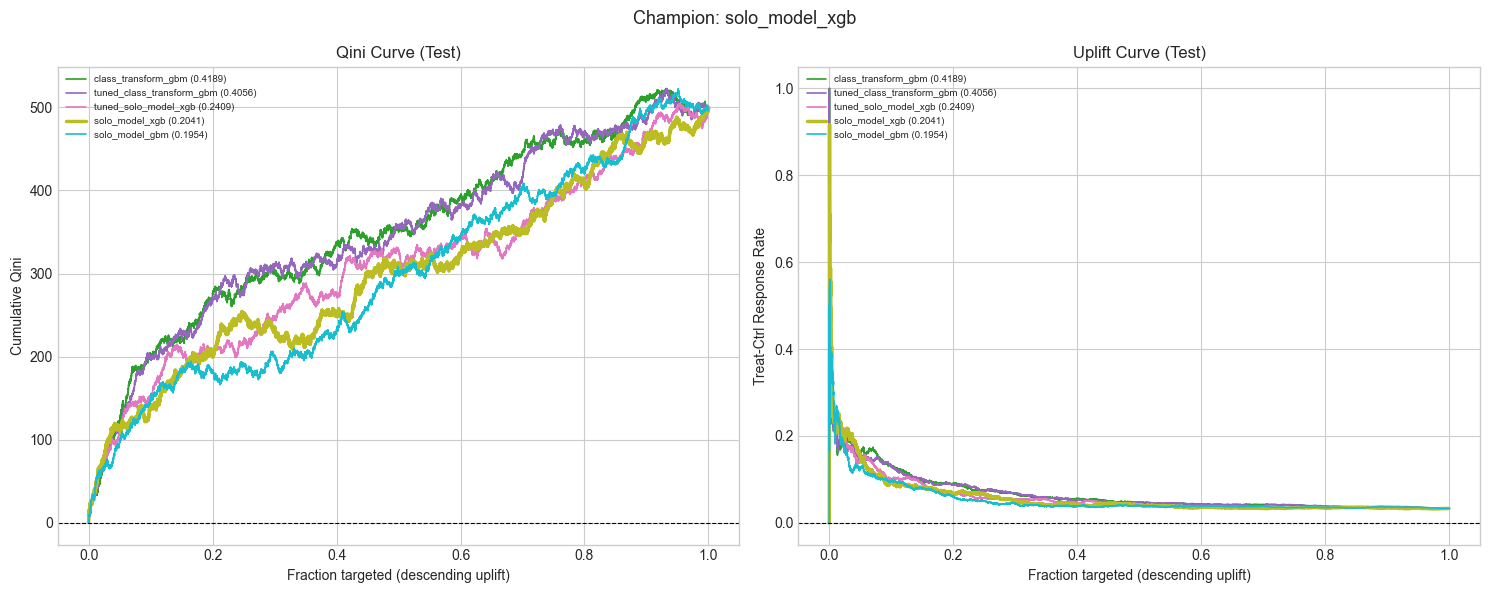

In [17]:
top5 = test_lb.drop(index='random_baseline', errors='ignore').head(5).index.tolist()
plot_m = ['random_baseline'] + top5
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_m)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, mn in enumerate(plot_m):
    m = all_models.get(mn)
    if m is None: continue
    sc = m.predict_uplift(test_df)
    lw = 2.5 if mn == champion_name else 1.2
    lbl = f'{mn} ({test_lb.loc[mn, "normalized_qini_auc"]:.4f})'
    q = qini_curve_data(y_test, t_test, sc)
    axes[0].plot(q['fraction'], q['qini'], color=colors[i], lw=lw, label=lbl)
    u = uplift_curve_data(y_test, t_test, sc)
    axes[1].plot(u['fraction'], u['uplift'], color=colors[i], lw=lw, label=lbl)

for ax, ttl, yl in [(axes[0], 'Qini Curve (Test)', 'Cumulative Qini'),
                    (axes[1], 'Uplift Curve (Test)', 'Treat-Ctrl Response Rate')]:
    ax.axhline(0, color='black', linestyle='--', lw=0.8)
    ax.set_title(ttl, fontsize=12)
    ax.set_xlabel('Fraction targeted (descending uplift)')
    ax.set_ylabel(yl); ax.legend(fontsize=7, loc='upper left')

plt.suptitle(f'Champion: {champion_name}', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'qini_uplift_curves.png', bbox_inches='tight', dpi=120)
plt.show()


=== Champion Decile Table (solo_model_xgb) ===


,decile,n,treated_n,control_n,treated_rr,control_rr,obs_uplift,pred_uplift
0,1,3001,1495,1506,0.5472,0.4548,0.0923,0.0926
1,2,3001,1537,1464,0.5218,0.4822,0.0396,0.0524
2,3,3001,1510,1491,0.5291,0.5057,0.0234,0.0394
3,4,3001,1455,1546,0.5485,0.5349,0.0135,0.0309
4,5,3001,1523,1478,0.6034,0.5656,0.0378,0.0242
5,6,3001,1494,1507,0.6091,0.5999,0.0092,0.0185
6,7,3000,1513,1487,0.6702,0.6530,0.0172,0.0136
7,8,3000,1501,1499,0.7575,0.7191,0.0383,0.0093
8,9,3000,1526,1474,0.7962,0.7626,0.0336,0.0054
9,10,3000,1443,1557,0.7859,0.7514,0.0344,0.0011


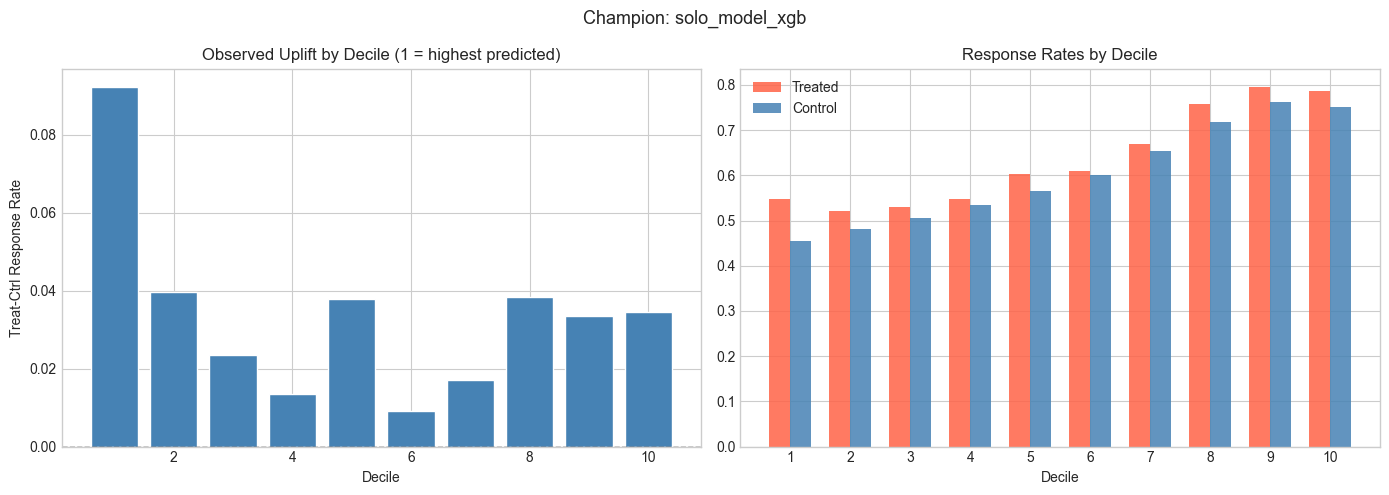

In [18]:
champ_dec = decile_table(y_test, t_test, test_scores)
print(f'=== Champion Decile Table ({champion_name}) ==='); display(champ_dec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bc = ['tomato' if v < 0 else 'steelblue' for v in champ_dec['obs_uplift']]
axes[0].bar(champ_dec['decile'], champ_dec['obs_uplift'], color=bc, edgecolor='white')
axes[0].axhline(0, color='black', linestyle='--', lw=1)
axes[0].set_title('Observed Uplift by Decile (1 = highest predicted)')
axes[0].set_xlabel('Decile'); axes[0].set_ylabel('Treat-Ctrl Response Rate')

x = np.arange(len(champ_dec)); w = 0.35
axes[1].bar(x-w/2, champ_dec['treated_rr'], w, label='Treated', color='tomato', alpha=0.85)
axes[1].bar(x+w/2, champ_dec['control_rr'], w, label='Control', color='steelblue', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(champ_dec['decile'])
axes[1].set_title('Response Rates by Decile')
axes[1].set_xlabel('Decile'); axes[1].legend()

plt.suptitle(f'Champion: {champion_name}', fontsize=13); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'champion_decile.png', bbox_inches='tight', dpi=120); plt.show()


## 9. Feature Importance & XAI

Native importance (from the treatment-arm model) + permutation importance (Δ normalized Qini AUC when each feature is shuffled on a 2k validation sample).

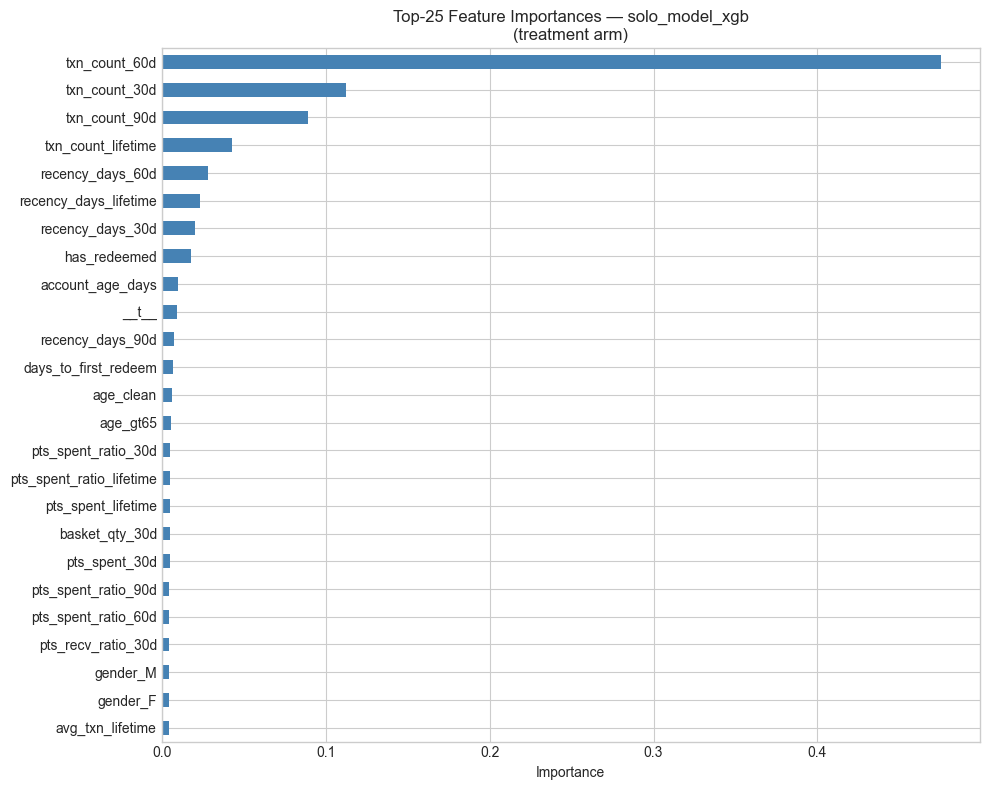

,importance
txn_count_60d,0.4754
txn_count_30d,0.1124
txn_count_90d,0.0893
txn_count_lifetime,0.0426
recency_days_60d,0.0282
recency_days_lifetime,0.0236
recency_days_30d,0.0202
has_redeemed,0.0177
account_age_days,0.0099
__t__,0.0093



Permutation importance on 2000-row val sample...
Baseline normalized Qini (sample): 0.41643


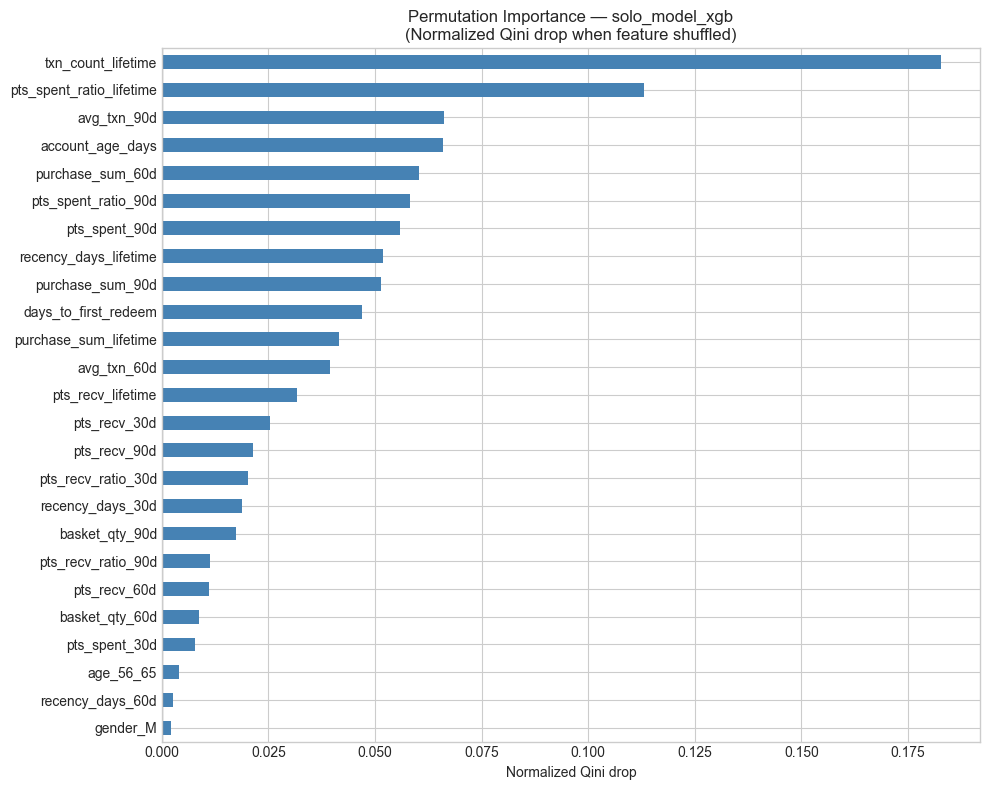

,normalized_qini_drop
txn_count_lifetime,0.1827
pts_spent_ratio_lifetime,0.1132
avg_txn_90d,0.0661
account_age_days,0.0660
purchase_sum_60d,0.0604
pts_spent_ratio_90d,0.0583
pts_spent_90d,0.0559
recency_days_lifetime,0.0519
purchase_sum_90d,0.0514
days_to_first_redeem,0.0471


In [19]:
def get_native_imp(m):
    underlying = m.treat_model if m.family == 'two_model' else m.model
    if underlying is None: return None
    if hasattr(underlying, 'named_steps'):
        underlying = underlying.named_steps.get('clf', underlying)
    cols = list(m.feat_cols)
    if m.family == 'solo_model':
        cols = cols + ['__t__']
    if hasattr(underlying, 'feature_importances_'):
        values = np.asarray(underlying.feature_importances_)
        if len(values) != len(cols):
            cols = [f'feature_{i}' for i in range(len(values))]
        return pd.Series(values, index=cols).sort_values(ascending=False)
    if hasattr(underlying, 'coef_'):
        values = np.abs(np.asarray(underlying.coef_).ravel())
        if len(values) != len(cols):
            cols = [f'feature_{i}' for i in range(len(values))]
        return pd.Series(values, index=cols).sort_values(ascending=False)
    return None

nimp = get_native_imp(champion)
if nimp is not None:
    top25 = nimp.head(25)
    fig, ax = plt.subplots(figsize=(10, 8))
    top25[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top-25 Feature Importances — {champion_name}\n(treatment arm)')
    ax.set_xlabel('Importance'); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', bbox_inches='tight', dpi=120); plt.show()
    display(top25.to_frame('importance'))
else:
    print('Native importance not available for this model type.')

# Permutation importance
print('\nPermutation importance on 2000-row val sample...')
vs = val_df.sample(min(2000, len(val_df)), random_state=RANDOM_SEED)
ys = vs[TARGET_COL].values; ts = vs[TREATMENT_COL].values
bq = normalized_qini_auc(ys, ts, champion.predict_uplift(vs))
print(f'Baseline normalized Qini (sample): {bq:.5f}')

pimp = {}
for feat in FEATURE_COLS:
    sh = vs.copy(); sh[feat] = sh[feat].sample(frac=1, random_state=RANDOM_SEED).values
    pimp[feat] = bq - normalized_qini_auc(ys, ts, champion.predict_uplift(sh))

ps = pd.Series(pimp).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
t25 = ps.head(25)
bc = ['tomato' if v < 0 else 'steelblue' for v in t25.values[::-1]]
t25[::-1].plot(kind='barh', ax=ax, color=bc)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Permutation Importance — {champion_name}\n(Normalized Qini drop when feature shuffled)')
ax.set_xlabel('Normalized Qini drop'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_importance.png', bbox_inches='tight', dpi=120); plt.show()
display(ps.head(25).to_frame('normalized_qini_drop'))


## 10. Customer Segmentation

| Segment | Uplift | P(buy\|T) | P(buy\|C) | Action |
|---|---|---|---|---|
| **Persuadables** | High | High | Low | **Promote** |
| **Sure Things** | ~0 | High | High | **Skip** — buy anyway |
| **Lost Causes** | ~0 | Low | Low | **Skip** — promo won't help |
| **Sleeping Dogs** | Negative | Low | High | **Avoid** — promo hurts |

In [20]:
X_t = test_df[champion.feat_cols].apply(pd.to_numeric, errors='coerce')
if champion.family == 'two_model':
    p_t = pp(champion.treat_model, X_t); p_c = pp(champion.ctrl_model, X_t)
elif champion.family == 'solo_model':
    Xt = X_t.copy(); Xt['__t__'] = 1; Xc = X_t.copy(); Xc['__t__'] = 0
    p_t = pp(champion.model, Xt); p_c = pp(champion.model, Xc)
elif champion.family == 'response_model':
    p_t = pp(champion.model, X_t); p_c = p_t.copy()
else:
    p_t = test_scores; p_c = np.zeros_like(p_t)

seg_df = pd.DataFrame({
    'client_id': test_df['client_id'].values,
    'uplift_score': test_scores, 'p_treat': p_t, 'p_ctrl': p_c,
    'true_target': y_test, 'true_treatment': t_test,
})

up75 = np.percentile(test_scores, 75); up25 = np.percentile(test_scores, 25)
PH = 0.40; PL = 0.25
print(f'Uplift p25={up25:.4f}  p75={up75:.4f}  |  P_HIGH={PH}  P_LOW={PL}')

def segment(r):
    u = r['uplift_score']; pt = r['p_treat']; pc = r['p_ctrl']
    if u >= up75 and pt >= PH and pc < PH:  return 'Persuadable'
    if u < 0  and pc >= PH and pt < PH:     return 'Sleeping Dog'
    if pt >= PH and pc >= PH:               return 'Sure Thing'
    if pt < PL  and pc < PL:                return 'Lost Cause'
    return 'Uncertain'

seg_df['segment'] = seg_df.apply(segment, axis=1)
ss = seg_df.groupby('segment').agg(
    count=('client_id','count'), avg_uplift=('uplift_score','mean'),
    avg_p_treat=('p_treat','mean'), avg_p_ctrl=('p_ctrl','mean')).reset_index()
ss['pct'] = (ss['count'] / len(seg_df) * 100).round(1)
ss = ss.sort_values('avg_uplift', ascending=False)
print('=== Customer Segment Summary ==='); display(ss)


Uplift p25=0.0093  p75=0.0392  |  P_HIGH=0.4  P_LOW=0.25
=== Customer Segment Summary ===


,segment,count,avg_uplift,avg_p_treat,avg_p_ctrl,pct
1,Persuadable,1202,0.0894,0.4476,0.3582,4.0000
4,Uncertain,4125,0.0330,0.3388,0.3058,13.7000
3,Sure Thing,22977,0.0256,0.7306,0.7049,76.6000
0,Lost Cause,1699,0.0175,0.1942,0.1767,5.7000
2,Sleeping Dog,3,-0.0073,0.3975,0.4048,0.0000


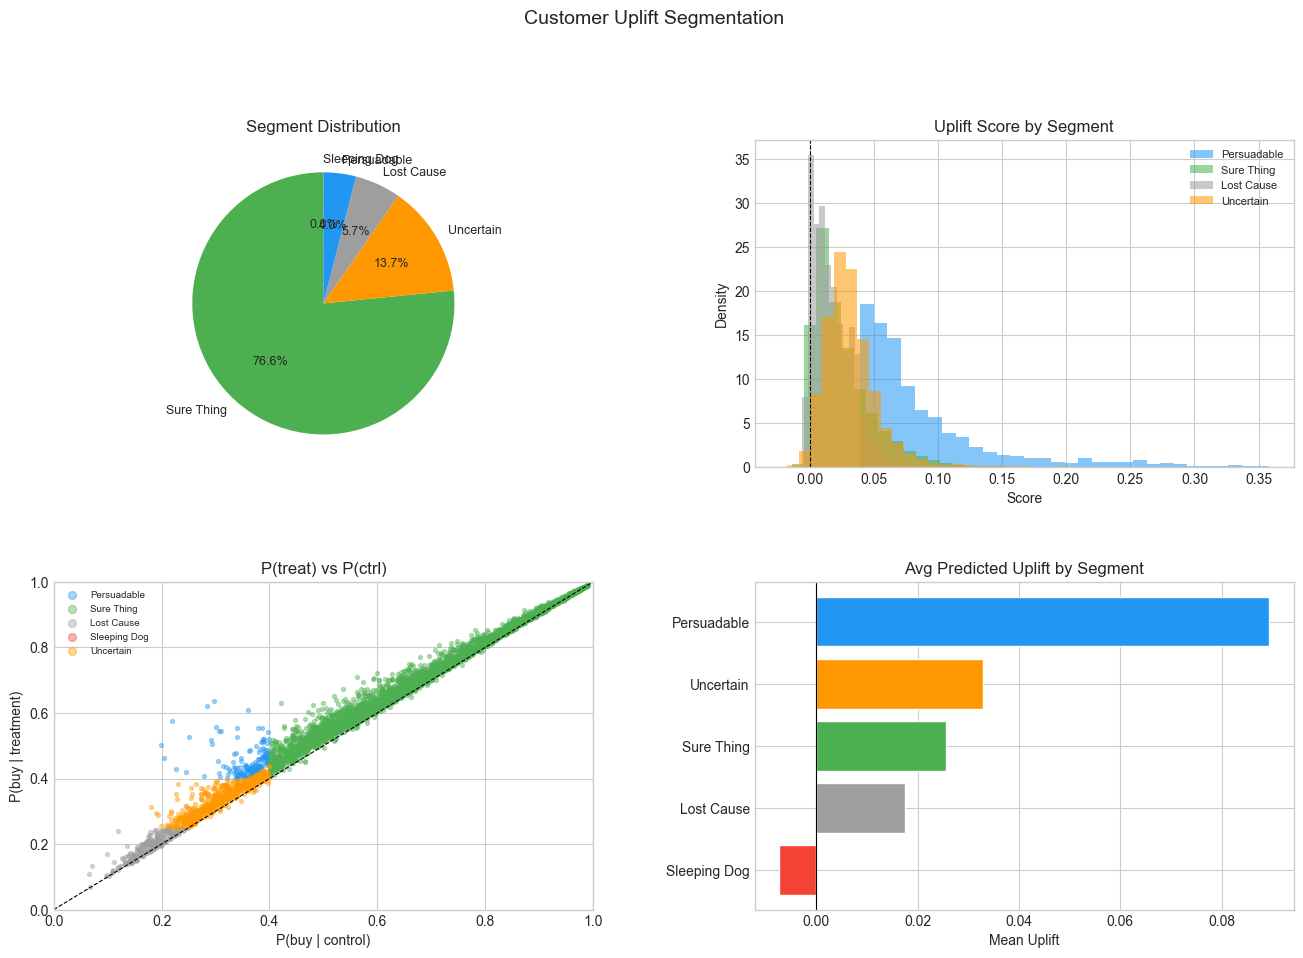

In [21]:
SC = {'Persuadable': '#2196F3', 'Sure Thing': '#4CAF50',
      'Lost Cause': '#9E9E9E', 'Sleeping Dog': '#F44336', 'Uncertain': '#FF9800'}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax0 = fig.add_subplot(gs[0, 0])
cnts = seg_df['segment'].value_counts()
ax0.pie(cnts.values, labels=cnts.index,
        colors=[SC.get(s,'gray') for s in cnts.index],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax0.set_title('Segment Distribution')

ax1 = fig.add_subplot(gs[0, 1])
for seg, color in SC.items():
    sub = seg_df[seg_df['segment'] == seg]['uplift_score']
    if len(sub) > 5: ax1.hist(sub, bins=30, alpha=0.55, label=seg, color=color, density=True)
ax1.axvline(0, color='black', linestyle='--', lw=0.8)
ax1.set_title('Uplift Score by Segment'); ax1.set_xlabel('Score')
ax1.set_ylabel('Density'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1, 0])
smp = seg_df.sample(min(4000, len(seg_df)), random_state=RANDOM_SEED)
for seg, color in SC.items():
    sub = smp[smp['segment'] == seg]
    ax2.scatter(sub['p_ctrl'], sub['p_treat'], c=color, alpha=0.4, s=8, label=seg)
ax2.plot([0,1],[0,1],'k--',lw=0.8); ax2.set_xlim(0,1); ax2.set_ylim(0,1)
ax2.set_xlabel('P(buy | control)'); ax2.set_ylabel('P(buy | treatment)')
ax2.set_title('P(treat) vs P(ctrl)'); ax2.legend(fontsize=7, markerscale=2)

ax3 = fig.add_subplot(gs[1, 1])
so = ss.sort_values('avg_uplift', ascending=True)
ax3.barh(so['segment'], so['avg_uplift'],
         color=[SC.get(s,'gray') for s in so['segment']], edgecolor='white')
ax3.axvline(0, color='black', lw=0.8)
ax3.set_title('Avg Predicted Uplift by Segment'); ax3.set_xlabel('Mean Uplift')

plt.suptitle('Customer Uplift Segmentation', fontsize=14, y=1.01)
plt.savefig(OUTPUT_DIR / 'customer_segmentation.png', bbox_inches='tight', dpi=120); plt.show()


In [22]:
seg_w = seg_df.merge(feature_table, on='client_id', how='left')
prof_cols = [c for c in ['age_clean','gender_F','gender_M','has_redeemed','account_age_days',
    'days_to_first_redeem','txn_count_lifetime','purchase_sum_lifetime',
    'recency_days_lifetime','txn_count_90d','purchase_sum_90d'] if c in seg_w.columns]
print('=== Segment Profiles ===')
display(seg_w.groupby('segment')[prof_cols].mean().round(2).T)

prs = seg_w[seg_w['segment'] == 'Persuadable']
oth = seg_w[seg_w['segment'] != 'Persuadable']
print(f'\nPersuadables: {len(prs):,}  Others: {len(oth):,}')
rows = []
for col in prof_cols:
    a = prs[col].dropna(); b = oth[col].dropna()
    if len(a) > 5 and len(b) > 5:
        _, pv = stats.mannwhitneyu(a, b, alternative='two-sided')
        rows.append({'feature': col, 'persuadable_mean': round(a.mean(),3),
                     'others_mean': round(b.mean(),3), 'diff': round(a.mean()-b.mean(),3),
                     'p_value': round(pv,5), 'sig': pv < 0.05})
display(pd.DataFrame(rows).sort_values('p_value'))


=== Segment Profiles ===


segment,Lost Cause,Persuadable,Sleeping Dog,Sure Thing,Uncertain
age_clean,41.2200,49.5600,43.0000,46.9100,43.4400
gender_F,0.3000,0.3800,0.0000,0.3800,0.3300
gender_M,0.1600,0.1500,0.3300,0.1700,0.1600
has_redeemed,0.4000,0.9900,0.3300,0.9600,0.8300
account_age_days,383.9600,374.0300,264.7000,441.4200,424.4000
days_to_first_redeem,94.3000,154.4100,80.0300,166.9300,180.2100
txn_count_lifetime,2.9400,7.5700,12.6700,24.4500,5.8500
purchase_sum_lifetime,1602.7000,3066.5700,6093.0000,10290.6800,3284.5600
recency_days_lifetime,12.5600,9.7400,18.7900,4.6400,11.1600
txn_count_90d,2.3500,5.5900,11.0000,19.4600,4.6200



Persuadables: 1,202  Others: 28,804


,feature,persuadable_mean,others_mean,diff,p_value,sig
0,age_clean,49.5580,46.0790,3.4790,0.0000,True
3,has_redeemed,0.9850,0.9090,0.0760,0.0000,True
4,account_age_days,374.0330,435.5730,-61.5400,0.0000,True
6,txn_count_lifetime,7.5720,20.5150,-12.9430,0.0000,True
7,purchase_sum_lifetime,3066.5650,8774.4390,-5707.8740,0.0000,True
8,recency_days_lifetime,9.7380,6.0420,3.6960,0.0000,True
9,txn_count_90d,5.5940,16.3210,-10.7270,0.0000,True
10,purchase_sum_90d,2244.7610,7052.5310,-4807.7710,0.0000,True
2,gender_M,0.1470,0.1660,-0.0190,0.0856,False
1,gender_F,0.3790,0.3690,0.0100,0.4874,False


## 11. Policy Analysis

Policy gain at different targeting cutoffs under zero / low / medium communication cost.

scenario,cutoff%,n_contacted,obs_uplift,low_cost,medium_cost,zero_cost
0,5,1501,0.1552,217.9000,157.8600,232.9100
1,10,3001,0.0923,247.0100,126.9700,277.0200
2,20,6002,0.0659,335.8200,95.7400,395.8400
3,30,9002,0.0519,376.9000,16.8200,466.9200
4,40,12003,0.0418,381.3100,-98.8100,501.3400
5,50,15003,0.0414,470.7900,-129.3300,620.8200


,threshold_pct,n_targeted,lift_rate,incremental_conversions,total_cost,estimated_revenue_lift,roi
0,5,1501,0.1552,232.9100,1501.0000,2329.0700,0.5520
1,10,3001,0.0923,277.0200,3001.0000,2770.2200,-0.0770
2,20,6002,0.0660,395.8400,6002.0000,3958.3800,-0.3400
3,30,9002,0.0519,466.9200,9002.0000,4669.1600,-0.4810



=== Recommended Threshold ===
Recommended threshold: top 5% (1,501 customers)
Lift rate: 0.1552  |  Incremental conversions: 232.91  |  ROI: 0.552
Rationale: highest positive ROI, with lift rate used as the tie-breaker
Optimal (zero-cost): top 50% (15,003 customers, gain=620.8)


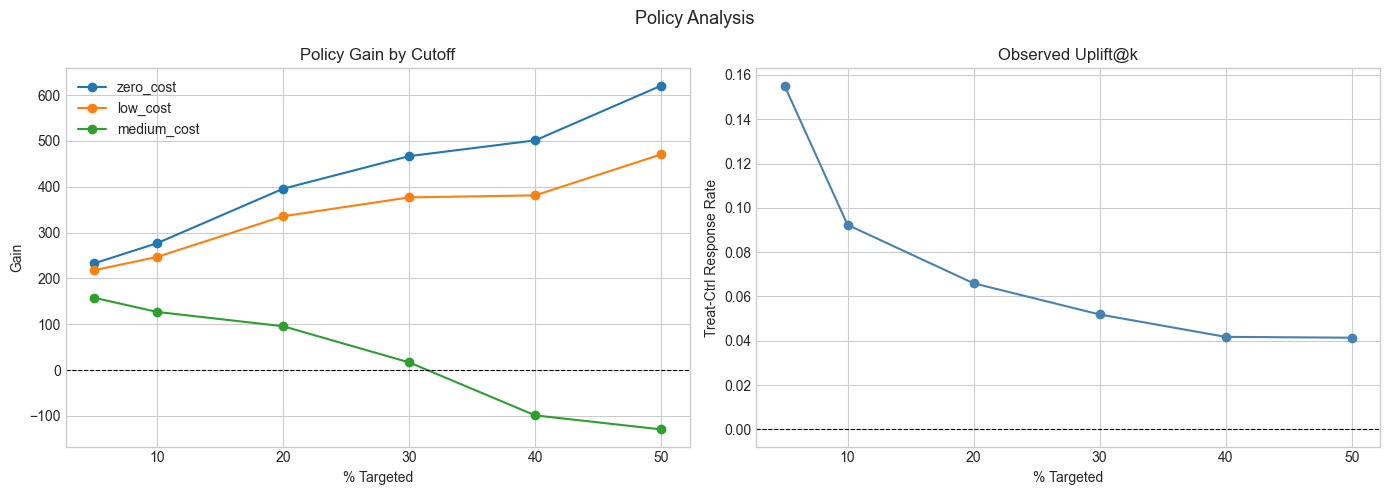

In [23]:
cutoffs = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
cost_sc = {'zero_cost': 0.0, 'low_cost': 0.01, 'medium_cost': 0.05}
coupon_cost = 1.0
revenue_per_conversion = 10.0
n_t = len(test_df); rows = []
policy_rows = []

for cutoff in cutoffs:
    obs = uplift_at_k(y_test, t_test, test_scores, k=cutoff)
    nc = int(np.ceil(n_t * cutoff))
    incremental = obs * nc if not np.isnan(obs) else np.nan
    total_cost = nc * coupon_cost
    revenue_lift = incremental * revenue_per_conversion if not np.isnan(incremental) else np.nan
    roi = (revenue_lift - total_cost) / total_cost if not np.isnan(revenue_lift) and total_cost > 0 else np.nan
    if cutoff in CUTOFF_GRID:
        policy_rows.append({'threshold_pct': int(round(cutoff * 100)), 'n_targeted': nc,
                            'lift_rate': round(float(obs), 4) if not np.isnan(obs) else np.nan,
                            'incremental_conversions': round(float(incremental), 2) if not np.isnan(incremental) else np.nan,
                            'total_cost': round(float(total_cost), 2),
                            'estimated_revenue_lift': round(float(revenue_lift), 2) if not np.isnan(revenue_lift) else np.nan,
                            'roi': round(float(roi), 3) if not np.isnan(roi) else np.nan})
    for sc, cost in cost_sc.items():
        gain = obs * nc - nc * cost if not np.isnan(obs) else np.nan
        rows.append({'cutoff%': int(cutoff*100), 'n_contacted': nc,
                     'obs_uplift': round(obs,5), 'scenario': sc,
                     'gain': round(float(gain),2) if not np.isnan(gain) else np.nan})

pol = pd.DataFrame(rows)
display(pol.pivot_table(index=['cutoff%','n_contacted','obs_uplift'],
                         columns='scenario', values='gain').reset_index())

policy_table = pd.DataFrame(policy_rows)
display(policy_table)

eligible_policy = policy_table.dropna(subset=['roi', 'lift_rate']).copy()
eligible_policy = eligible_policy[eligible_policy['roi'] > 0]
if eligible_policy.empty:
    recommended_policy = policy_table.sort_values('lift_rate', ascending=False).iloc[0]
    recommendation_rationale = 'highest observed uplift because no positive-ROI cutoff was available'
else:
    recommended_policy = eligible_policy.sort_values(['roi', 'lift_rate', 'threshold_pct'], ascending=[False, False, True]).iloc[0]
    recommendation_rationale = 'highest positive ROI, with lift rate used as the tie-breaker'
recommended_threshold_pct = int(recommended_policy['threshold_pct'])
print('\n=== Recommended Threshold ===')
print(f"Recommended threshold: top {recommended_threshold_pct}% "
      f"({int(recommended_policy['n_targeted']):,} customers)")
print(f"Lift rate: {recommended_policy['lift_rate']:.4f}  |  "
      f"Incremental conversions: {recommended_policy['incremental_conversions']:.2f}  |  "
      f"ROI: {recommended_policy['roi']:.3f}")
print('Rationale:', recommendation_rationale)

opt = pol[pol['scenario']=='zero_cost']
opt = opt.loc[opt['gain'].idxmax()]
print(f"Optimal (zero-cost): top {opt['cutoff%']}% ({opt['n_contacted']:,} customers, gain={opt['gain']:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc in cost_sc:
    sub = pol[pol['scenario'] == sc]
    axes[0].plot(sub['cutoff%'], sub['gain'], marker='o', label=sc)
axes[0].axhline(0, color='black', linestyle='--', lw=0.8)
axes[0].set_title('Policy Gain by Cutoff'); axes[0].legend()
axes[0].set_xlabel('% Targeted'); axes[0].set_ylabel('Gain')

zc = pol[pol['scenario'] == 'zero_cost']
axes[1].plot(zc['cutoff%'], zc['obs_uplift'], marker='o', color='steelblue')
axes[1].axhline(0, color='black', linestyle='--', lw=0.8)
axes[1].set_title('Observed Uplift@k'); axes[1].set_xlabel('% Targeted')
axes[1].set_ylabel('Treat-Ctrl Response Rate')

plt.suptitle('Policy Analysis', fontsize=13); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'policy_analysis.png', bbox_inches='tight', dpi=120); plt.show()


## 12. Summary & Business Recommendations

In [24]:
full_lb.to_csv(OUTPUT_DIR / 'cv_leaderboard.csv')
full_lb.to_csv(OUTPUT_DIR / 'val_leaderboard.csv')  # backward-compatible filename for prior notebook consumers
test_lb.to_csv(OUTPUT_DIR / 'test_leaderboard.csv')
champ_dec.to_csv(OUTPUT_DIR / 'champion_decile_table.csv', index=False)
ss.to_csv(OUTPUT_DIR / 'segment_summary.csv', index=False)
seg_df.to_csv(OUTPUT_DIR / 'segment_assignments_test.csv', index=False)
policy_table.to_csv(OUTPUT_DIR / 'policy_recommendations.csv', index=False)
print(f'Artefacts saved to {OUTPUT_DIR}/')

print()
print('='*70)
print('HUMAN BASELINE - FINAL SUMMARY')
print('='*70)
print(f'Champion : {champion_name}  (family={champion.family}, base={champion.base})')
print()
print('[Cross-validation]')
for k in ['normalized_qini_auc','raw_qini_auc','uplift_auc','uplift@10%','uplift@30%']:
    print(f'  {k:<18}: {full_lb.loc[champion_name,k]:.5f}')
print(f'  CV std norm_qini : {full_lb.loc[champion_name,"normalized_qini_auc_std"]:.5f}')
print()
print('[Held-out Test]')
for k in ['normalized_qini_auc','raw_qini_auc','uplift_auc','uplift@10%','uplift@30%']:
    print(f'  {k:<18}: {test_lb.loc[champion_name,k]:.5f}')
print()
print('[Segments (test set)]')
for _, r in ss.iterrows():
    print(f'  {r["segment"]:14s}: {r["count"]:6,} ({r["pct"]:.1f}%)  avg_uplift={r["avg_uplift"]:.4f}')
print()
print('[Recommended Threshold]')
print(f'  top {recommended_threshold_pct}% ({int(recommended_policy["n_targeted"]):,} customers)  '
      f'lift={recommended_policy["lift_rate"]:.4f}  roi={recommended_policy["roi"]:.3f}')
print()
print('[Business Actions]')
print('  PROMOTE  -> Persuadables : incremental buyers - best promotion ROI')
print('  SKIP     -> Sure Things  : buy regardless - promotion is wasted spend')
print('  SKIP     -> Lost Causes  : low propensity - promotion has no effect')
print('  AVOID    -> Sleeping Dogs: promotion REDUCES purchase - do not contact')
print('='*70)


Artefacts saved to artifacts\human_baseline/

HUMAN BASELINE - FINAL SUMMARY
Champion : solo_model_xgb  (family=solo_model, base=xgboost)

[Cross-validation]
  normalized_qini_auc: 0.40949
  raw_qini_auc      : 396.14646
  uplift_auc        : 0.06532
  uplift@10%        : 0.11032
  uplift@30%        : 0.07041
  CV std norm_qini : 0.08755

[Held-out Test]
  normalized_qini_auc: 0.20412
  raw_qini_auc      : 299.12559
  uplift_auc        : 0.05782
  uplift@10%        : 0.09231
  uplift@30%        : 0.05187

[Segments (test set)]
  Persuadable   :  1,202 (4.0%)  avg_uplift=0.0894
  Uncertain     :  4,125 (13.7%)  avg_uplift=0.0330
  Sure Thing    : 22,977 (76.6%)  avg_uplift=0.0256
  Lost Cause    :  1,699 (5.7%)  avg_uplift=0.0175
  Sleeping Dog  :      3 (0.0%)  avg_uplift=-0.0073

[Recommended Threshold]
  top 5% (1,501 customers)  lift=0.1552  roi=0.552

[Business Actions]
  PROMOTE  -> Persuadables : incremental buyers - best promotion ROI
  SKIP     -> Sure Things  : buy regardless 